# SpaPath multiple myeloma workflows

This notebook compares four reference configurations for the hMM2 disease section: scATAC alone, scRNA alone, ST alone, and all three references together. Each workflow ends after constructing the all-gene disease dataset.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import scanpy as sc

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import spapath_model
import spapath_utils

warnings.filterwarnings("ignore")

In [2]:
DATASET_ID = "MM"
DISEASE_SECTION = "hMM2"
DEVICE = "cuda"
SEED = 123

DATA_ROOT = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_ROOT / DATASET_ID
OUTPUT_DIR = PROJECT_ROOT / "outputs" / DATASET_ID
FIGURE_DIR = OUTPUT_DIR / "fig"

for output_path in (OUTPUT_DIR, FIGURE_DIR):
    spapath_utils.create_dir(output_path)

REFERENCE_CONFIGS = {
    "scATAC": {"hHBM_scATAC": "scATAC"},
    "scRNA": {"hHBM_scRNA": "sc"},
    "ST": {"hHBM1_ST": "ST"},
    "combined": {
        "hHBM_scATAC": "scATAC",
        "hHBM_scRNA": "sc",
        "hHBM1_ST": "ST",
    },
}

/home/wuyd/SpaPath/outputs/MM has been created or already exists.
/home/wuyd/SpaPath/outputs/MM/fig has been created or already exists.


## 1. Shared workflow

In [3]:
def run_reference_workflow(reference_type_map, run_name):
    adata_type_map = {
        **reference_type_map,
        DISEASE_SECTION: "ST",
    }
    sections = list(adata_type_map)

    reference_adatas = [
        sc.read_h5ad(PROCESSED_DIR / f"{section}.h5ad")
        for section in reference_type_map
    ]
    disease_adata = sc.read_h5ad(
        PROCESSED_DIR / f"{DISEASE_SECTION}.h5ad"
    )

    if "image_embedding" not in disease_adata.obsm:
        raise KeyError(
            f"{DISEASE_SECTION} is missing .obsm['image_embedding']."
        )
    image_embedding_dim = disease_adata.obsm["image_embedding"].shape[1]
    for reference_adata in reference_adatas:
        if "image_embedding" not in reference_adata.obsm:
            reference_adata.obsm["image_embedding"] = np.zeros(
                (reference_adata.n_obs, image_embedding_dim),
                dtype=np.float32,
            )

    batch_list = [*reference_adatas, disease_adata]
    adata_full, disease_adata_all_genes = spapath_utils.preprocess(
        adata_list=batch_list,
        adata_type_map=adata_type_map,
        full_num_hvgs=3000,
        min_genes_qc=10,
        min_cells_qc=10,
    )
    adata_full = spapath_utils.build_graph_GAT_plus(
        adata_full=adata_full,
        adata_type_map=adata_type_map,
        K=8,
        img_threshold=0.0,
    )

    model = spapath_model.Model(
        adata_full=adata_full,
        adata_type_map=adata_type_map,
        lr_pre=1e-4,
        lr=1e-4,
        n_pre_training_steps=500,
        n_training_steps=300,
        device=DEVICE,
        seed=SEED,
    )
    adata_full = model.initial_embedding()
    adata_full = model.clustering(
        init_res=1.5,
        intopk=40,
    )
    adata_full = model.integrate(topk=40)

    adata_full = spapath_utils.detection(
        adata=adata_full,
        embed="cell_embed",
        section_ids=sections,
        label_core="Pathological regions",
        label_other="Healthy-like regions",
        core_types=None,
        celltype_key=None,
        batch_key="batch",
        seed=SEED,
        neighbors=30,
        threshold=0.05,
        strategy="individual",
    )

    spapath_utils.plot_detection_umap(
        adata=adata_full,
        embed="cell_embed",
        section_id=DISEASE_SECTION,
        batch_key="batch",
        label_key="pred_label",
        seed=SEED,
        point_size=18,
        save=FIGURE_DIR / f"{DISEASE_SECTION}_{run_name}_detection_umap.png",
    )

    disease_data = spapath_utils.build_disease_data(
        adata_full=adata_full,
        disease_adata_all_genes=disease_adata_all_genes,
        disease_section=DISEASE_SECTION,
    )
    return adata_full, disease_data

## 2. scATAC reference

shape of adata 0 before quality control: (4990, 24919)
shape of adata 0 after quality control: (4990, 24734)
shape of adata 1 before quality control: (876, 18074)
shape of adata 1 after quality control: (864, 17072)
Find 16717 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Skipping spatial graph for batch hHBM_scATAC (scATAC)
Building sparse graph for batch hMM2 (ST) using NearestNeighbors...
  Average neighbors for Slice hMM2: 8.00


Pretrain slice 1: 100%|██████████| 500/500 [00:01<00:00, 417.04it/s]


There are 14 initial clusters for Slice - 0
There are 13 initial clusters for Slice - 1
There are 2 clusters for Slice - 0 after merging.
There are 6 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:1880(0.377), 1:3110(0.623)
[Cluster size] Slice 1 after merge: 0:126(0.146), 1:508(0.588), 2:76(0.088), 3:72(0.083), 4:46(0.053), 5:36(0.042)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


  0%|          | 1/300 [00:01<09:02,  1.81s/it]

Integration step 0: matched target clusters [1]; far-cluster pool [0].
Training step 0: reconstruction=22.5683, inter-cluster=2.2355, intra-cluster=7.5962, geometry=452.8593.


...

Integration step 100: matched target clusters [1]; far-cluster pool [0, 2, 3, 4, 5].
Training step 100: reconstruction=22.7699, inter-cluster=0.0856, intra-cluster=8.1497, geometry=93.5842.


 69%|██████▊   | 206/300 [00:23<00:11,  8.49it/s]

Integration step 200: matched target clusters [1]; far-cluster pool [0, 2, 3, 4, 5].
Training step 200: reconstruction=22.5906, inter-cluster=0.0136, intra-cluster=8.2384, geometry=74.6410.


100%|██████████| 300/300 [00:32<00:00,  9.24it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.
Detection completed at the observation level.


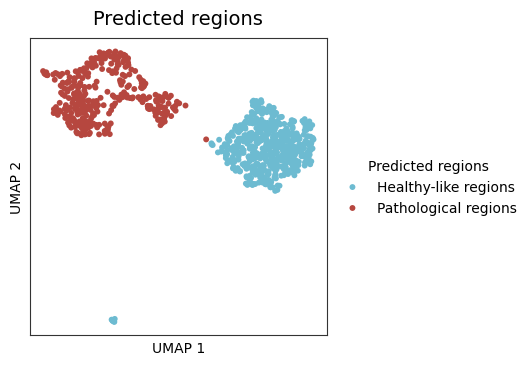

In [4]:
scatac_adata_full, scatac_disease_data = run_reference_workflow(
    reference_type_map=REFERENCE_CONFIGS["scATAC"],
    run_name="scATAC",
)

## 3. scRNA reference

shape of adata 0 before quality control: (2236, 27558)
shape of adata 0 after quality control: (2236, 11607)
shape of adata 1 before quality control: (876, 18074)
shape of adata 1 after quality control: (864, 17072)
Find 10319 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Skipping spatial graph for batch hHBM_scRNA (sc)
Building sparse graph for batch hMM2 (ST) using NearestNeighbors...
  Average neighbors for Slice hMM2: 8.00


Pretrain slice 1: 100%|██████████| 500/500 [00:01<00:00, 430.43it/s]


There are 16 initial clusters for Slice - 0
There are 13 initial clusters for Slice - 1
There are 10 clusters for Slice - 0 after merging.
There are 6 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:929(0.415), 1:252(0.113), 2:198(0.089), 3:173(0.077), 4:209(0.093), 5:116(0.052), 6:192(0.086), 7:82(0.037), 8:48(0.021), 9:37(0.017)
[Cluster size] Slice 1 after merge: 0:508(0.588), 1:133(0.154), 2:74(0.086), 3:60(0.069), 4:46(0.053), 5:43(0.050)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


  3%|▎         | 8/300 [00:00<00:14, 20.46it/s]

Integration step 0: matched target clusters [4]; far-cluster pool [2].
Training step 0: reconstruction=27.4916, inter-cluster=2.5128, intra-cluster=6.5309, geometry=421.8393.


...

Integration step 100: matched target clusters [1, 3, 4]; far-cluster pool [0, 2, 5].
Training step 100: reconstruction=27.6472, inter-cluster=0.8057, intra-cluster=6.9507, geometry=57.0637.


 69%|██████▊   | 206/300 [00:09<00:04, 19.22it/s]

Integration step 200: matched target clusters [1, 3, 4]; far-cluster pool [0, 2, 5].
Training step 200: reconstruction=27.4896, inter-cluster=0.2704, intra-cluster=6.9928, geometry=38.6384.


100%|██████████| 300/300 [00:13<00:00, 21.94it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.
Detection completed at the observation level.


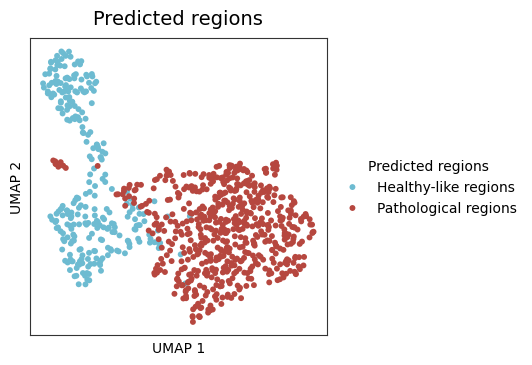

In [5]:
scrna_adata_full, scrna_disease_data = run_reference_workflow(
    reference_type_map=REFERENCE_CONFIGS["scRNA"],
    run_name="scRNA",
)

## 4. ST reference

shape of adata 0 before quality control: (2055, 18074)
shape of adata 0 after quality control: (1329, 17117)
shape of adata 1 before quality control: (876, 18074)
shape of adata 1 after quality control: (864, 17072)
Find 16573 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Building sparse graph for batch hHBM1_ST (ST) using NearestNeighbors...
  Average neighbors for Slice hHBM1_ST: 8.00
Building sparse graph for batch hMM2 (ST) using NearestNeighbors...
  Average neighbors for Slice hMM2: 8.00


Pretrain slice 1: 100%|██████████| 500/500 [00:01<00:00, 430.98it/s]


There are 13 initial clusters for Slice - 0
There are 13 initial clusters for Slice - 1
There are 5 clusters for Slice - 0 after merging.
There are 7 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:948(0.713), 1:198(0.149), 2:102(0.077), 3:65(0.049), 4:16(0.012)
[Cluster size] Slice 1 after merge: 0:551(0.638), 1:76(0.088), 2:60(0.069), 3:55(0.064), 4:52(0.060), 5:38(0.044), 6:32(0.037)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


  2%|▏         | 7/300 [00:00<00:18, 15.67it/s]

Integration step 0: matched target clusters [0]; far-cluster pool [1].
Training step 0: reconstruction=20.1771, inter-cluster=2.1416, intra-cluster=7.1668, geometry=551.5377.


...

Integration step 100: matched target clusters [0, 1, 5]; far-cluster pool [2, 3, 4, 6].
Training step 100: reconstruction=20.5219, inter-cluster=0.9341, intra-cluster=8.2253, geometry=68.7840.


 69%|██████▊   | 206/300 [00:10<00:04, 20.30it/s]

Integration step 200: matched target clusters [0, 5]; far-cluster pool [1, 2, 3, 4, 6].
Training step 200: reconstruction=20.2076, inter-cluster=0.0000, intra-cluster=8.1484, geometry=58.5407.


100%|██████████| 300/300 [00:14<00:00, 21.14it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.
Detection completed at the observation level.


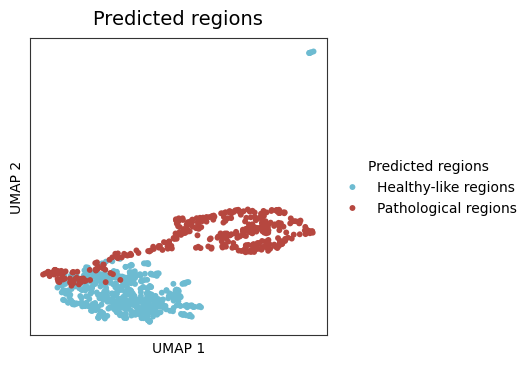

In [6]:
st_adata_full, st_disease_data = run_reference_workflow(
    reference_type_map=REFERENCE_CONFIGS["ST"],
    run_name="ST",
)

## 5. Combined scATAC, scRNA, and ST references

shape of adata 0 before quality control: (4990, 24919)
shape of adata 0 after quality control: (4990, 24734)
shape of adata 1 before quality control: (2236, 27558)
shape of adata 1 after quality control: (2236, 11607)
shape of adata 2 before quality control: (2055, 18074)
shape of adata 2 after quality control: (1329, 17117)
shape of adata 3 before quality control: (876, 18074)
shape of adata 3 after quality control: (864, 17072)
Find 9987 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Skipping spatial graph for batch hHBM_scATAC (scATAC)
Skipping spatial graph for batch hHBM_scRNA (sc)
Building sparse graph for batch hHBM1_ST (ST) using NearestNeighbors...
  Average neighbors for Slice hHBM1_ST: 8.00
Building sparse graph for batch hMM2 (ST) using NearestNeighbors...
  Average neighbors for Slice hMM2: 8.00


Pretrain slice 3: 100%|██████████| 500/500 [00:01<00:00, 453.52it/s]


There are 14 initial clusters for Slice - 0
There are 16 initial clusters for Slice - 1
There are 16 initial clusters for Slice - 2
There are 14 initial clusters for Slice - 3
There are 3 clusters for Slice - 0 after merging.
There are 11 clusters for Slice - 1 after merging.
There are 6 clusters for Slice - 2 after merging.
There are 6 clusters for Slice - 3 after merging.
[Cluster size] Slice 0 after merge: 0:1925(0.386), 1:2733(0.548), 2:332(0.067)
[Cluster size] Slice 1 after merge: 0:1041(0.466), 1:256(0.114), 2:183(0.082), 3:179(0.080), 4:155(0.069), 5:123(0.055), 6:76(0.034), 7:63(0.028), 8:61(0.027), 9:65(0.029), 10:34(0.015)
[Cluster size] Slice 2 after merge: 0:998(0.751), 1:101(0.076), 2:116(0.087), 3:78(0.059), 4:24(0.018), 5:12(0.009)
[Cluster size] Slice 3 after merge: 0:548(0.634), 1:73(0.084), 2:102(0.118), 3:55(0.064), 4:52(0.060), 5:34(0.039)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


  1%|▏         | 4/300 [00:01<01:37,  3.04it/s]

Integration step 0: matched target clusters [0, 5]; far-cluster pool [3].
Training step 0: reconstruction=27.9338, inter-cluster=2.1782, intra-cluster=7.4359, geometry=462.8243.


...

Integration step 100: matched target clusters [0, 1, 5]; far-cluster pool [2, 3, 4].
Training step 100: reconstruction=28.0880, inter-cluster=0.9023, intra-cluster=7.9091, geometry=48.6912.


 68%|██████▊   | 204/300 [00:25<00:16,  5.93it/s]

Integration step 200: matched target clusters [0, 1, 5]; far-cluster pool [2, 3, 4].
Training step 200: reconstruction=27.9080, inter-cluster=0.1699, intra-cluster=7.8742, geometry=44.2369.


100%|██████████| 300/300 [00:36<00:00,  8.29it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.
Detection completed at the observation level.


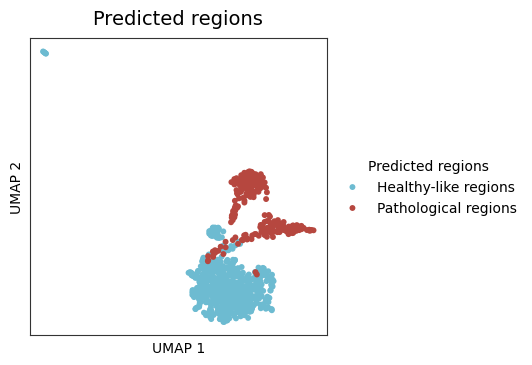

In [7]:
combined_adata_full, combined_disease_data = run_reference_workflow(
    reference_type_map=REFERENCE_CONFIGS["combined"],
    run_name="combined",
)